# 03 - Geo and climate analysis (extended, map-forward)

This notebook expands spatial diagnostics with map-based visualizations and
richer geodata analysis. It focuses on coverage, spatial patterns in outcomes,
climate/topography gradients, and multivariate structure.

In [1]:
from __future__ import annotations

from pathlib import Path
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

import geopandas as gpd
import contextily as ctx
from sklearn.cluster import KMeans

## Setup

In [2]:
USE_CACHED = True
FORCE_REBUILD = False
SAVE_PLOTS = False
SAVE_INTERACTIVE = False
RANDOM_SEED = 42


def find_repo_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for parent in [start] + list(start.parents):
        if (parent / "src").exists() and (parent / "data").exists():
            return parent
    raise RuntimeError("Could not locate repo root. Run from within the repo.")


REPO_ROOT = find_repo_root()
PYTHON = sys.executable

PROCESSED_DIR = REPO_ROOT / "data" / "processed"
EXTERNAL_DIR = REPO_ROOT / "data" / "external" / "processed"
OUTPUT_TABLES = REPO_ROOT / "outputs" / "tables"
PLOT_DIR = REPO_ROOT / "outputs" / "plots" / "notebooks"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110


PERU_BOUNDS = {
    "lon_min": -82.5,
    "lon_max": -68.0,
    "lat_min": -19.5,
    "lat_max": 1.5,
}


def run_cmd(cmd: list[str]) -> None:
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, cwd=REPO_ROOT, check=True)


def ensure_outputs(outputs: list[Path], cmd: list[str], label: str) -> None:
    outputs = [Path(p) for p in outputs]
    if USE_CACHED and not FORCE_REBUILD and all(p.exists() for p in outputs):
        print(f"[cache] {label}: using existing outputs")
        return
    run_cmd(cmd)


def load_table(parquet_path: Path, csv_path: Path, label: str) -> pd.DataFrame:
    try:
        return pd.read_parquet(parquet_path)
    except Exception as exc:
        if csv_path.exists():
            print(f"[warn] {label}: failed to read parquet ({exc}); using CSV")
            return pd.read_csv(csv_path)
        raise


def share_non_missing(df: pd.DataFrame, cols: list[str]) -> pd.Series:
    return df[cols].notna().mean().sort_values(ascending=False)


def safe_log1p(series: pd.Series) -> pd.Series:
    return np.log1p(series.where(series >= 0))


def add_basemap(ax: plt.Axes) -> None:
    try:
        ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, attribution=False)
    except Exception as exc:
        print(f"[warn] basemap unavailable: {exc}")


def to_web(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    return gdf.to_crs(epsg=3857)


def load_peru_boundary() -> gpd.GeoDataFrame:
    # GeoPandas sample datasets were removed in 1.0; fall back to cartopy Natural Earth.
    try:
        import geodatasets  # type: ignore

        path = geodatasets.get_path("naturalearth.land")
        world = gpd.read_file(path)
    except Exception:
        import cartopy.io.shapereader as shpreader  # type: ignore

        shp_path = shpreader.natural_earth(
            resolution="110m",
            category="cultural",
            name="admin_0_countries",
        )
        world = gpd.read_file(shp_path)

    candidates = ["ADMIN", "name", "NAME_EN", "SOVEREIGNT"]
    mask = pd.Series(False, index=world.index)
    for col in candidates:
        if col in world.columns:
            mask = mask | world[col].eq("Peru")
    return world.loc[mask].copy()

## External feature availability

This notebook does **not** download external datasets. If any of the files
below are missing, run the external download scripts separately.

In [3]:
expected_external = {
    "ubigeo": EXTERNAL_DIR / "ubigeo_district_capitals.parquet",
    "chirps": EXTERNAL_DIR / "chirps_district_features_2024.parquet",
    "temperature": EXTERNAL_DIR / "temperature_district_features_2023_2024.parquet",
    "topography": EXTERNAL_DIR / "topography_district_features.parquet",
}

for name, path in expected_external.items():
    print(f"{name}: {path.exists()} -> {path}")

can_merge = all(path.exists() for path in expected_external.values())
if not can_merge:
    print("One or more external feature files are missing. Skipping merge steps.")

ubigeo: True -> /Users/gabrielsaco/Documents/GitHub/sfa_ciup/data/external/processed/ubigeo_district_capitals.parquet
chirps: True -> /Users/gabrielsaco/Documents/GitHub/sfa_ciup/data/external/processed/chirps_district_features_2024.parquet
temperature: True -> /Users/gabrielsaco/Documents/GitHub/sfa_ciup/data/external/processed/temperature_district_features_2023_2024.parquet
topography: True -> /Users/gabrielsaco/Documents/GitHub/sfa_ciup/data/external/processed/topography_district_features.parquet


## Merge geo and climate features

The merge steps join existing processed data with geo/climate sources.

In [4]:
if can_merge:
    ensure_outputs(
        outputs=[PROCESSED_DIR / "model_data_ena2024_plus_geo.parquet", OUTPUT_TABLES / "06_geo_feature_coverage.csv"],
        cmd=[PYTHON, "src/features/merge_geo_features.py"],
        label="merge_geo_features",
    )

    ensure_outputs(
        outputs=[PROCESSED_DIR / "model_data_ena2024_plus_controls_temp.parquet", OUTPUT_TABLES / "12_temp_topo_coverage.csv"],
        cmd=[PYTHON, "src/features/merge_temperature_features.py"],
        label="merge_temperature_features",
    )

    ensure_outputs(
        outputs=[PROCESSED_DIR / "model_data_ena2024_plus_geo2.parquet", OUTPUT_TABLES / "12_temp_topo_coverage.csv"],
        cmd=[PYTHON, "src/features/merge_geo2_features.py"],
        label="merge_geo2_features",
    )

[cache] merge_geo_features: using existing outputs
[cache] merge_temperature_features: using existing outputs
[cache] merge_geo2_features: using existing outputs


## Load merged datasets

We load the "plus_geo" and "plus_geo2" datasets with robust fallback to CSV
to avoid parquet read failures.

In [5]:
geo = load_table(
    PROCESSED_DIR / "model_data_ena2024_plus_geo.parquet",
    PROCESSED_DIR / "model_data_ena2024_plus_geo.csv",
    label="plus_geo",
)

geo2 = load_table(
    PROCESSED_DIR / "model_data_ena2024_plus_geo2.parquet",
    PROCESSED_DIR / "model_data_ena2024_plus_geo2.csv",
    label="plus_geo2",
)

print("plus_geo shape:", geo.shape)
print("plus_geo2 shape:", geo2.shape)

plus_geo shape: (35187, 50)
plus_geo2 shape: (35187, 98)


## Prepare geospatial objects

Convert capital lat/lon to GeoDataFrame and filter to plausible Peru bounds.

In [6]:
geo2 = geo2.copy()

geo2["log1p_valor_total"] = safe_log1p(geo2.get("valor_total"))
geo2["log1p_prcp_2024_total"] = safe_log1p(geo2.get("prcp_2024_total"))

valid_coords = geo2[["capital_lon", "capital_lat"]].notna().all(axis=1)
geo2 = geo2.loc[valid_coords].copy()

bounds_mask = (
    geo2["capital_lon"].between(PERU_BOUNDS["lon_min"], PERU_BOUNDS["lon_max"]) &
    geo2["capital_lat"].between(PERU_BOUNDS["lat_min"], PERU_BOUNDS["lat_max"])
)
geo2 = geo2.loc[bounds_mask].copy()

geo_gdf = gpd.GeoDataFrame(
    geo2,
    geometry=gpd.points_from_xy(geo2["capital_lon"], geo2["capital_lat"]),
    crs="EPSG:4326",
)

peru = load_peru_boundary()

geo_web = to_web(geo_gdf)
peru_web = to_web(peru)

print("Geo points:", len(geo_gdf))

Geo points: 34075


## Coverage tables

Coverage tables summarize merge success. If missing, compute coverage directly.

In [7]:
geo_cov_path = OUTPUT_TABLES / "06_geo_feature_coverage.csv"
geo_cov = pd.read_csv(geo_cov_path) if geo_cov_path.exists() else None
geo_cov

,group_type,group,n,share_geo_match,share_chirps_match,mean_prcp_total_z,sd_prcp_total_z
0,overall,overall,35187,0.968397,0.968397,-0.448926,0.813300
1,region,1,8263,0.906329,0.906329,-0.458567,0.528105
2,region,2,20601,0.990437,0.990437,-0.290769,0.774407
3,region,3,6323,0.977700,0.977700,-0.959249,0.992875


In [8]:
coverage_vars = [
    "capital_lat",
    "prcp_2024_total",
    "tmean_2024",
    "elev_m",
    "slope_deg",
    "ruggedness",
]
coverage_vars = [c for c in coverage_vars if c in geo2.columns]
coverage_summary = share_non_missing(geo2, coverage_vars)
coverage_summary

capital_lat        1.000000
prcp_2024_total    1.000000
tmean_2024         1.000000
ruggedness         1.000000
elev_m             0.999325
slope_deg          0.998973
dtype: float64

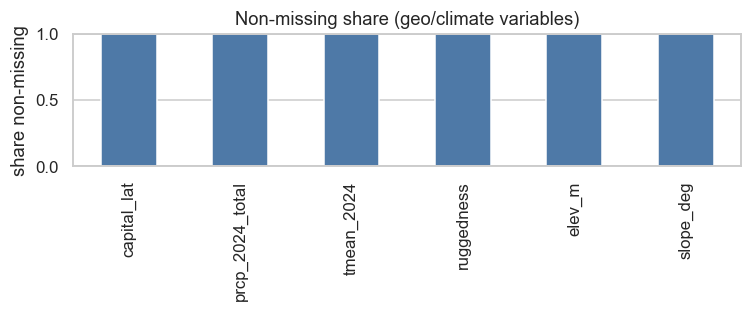

In [9]:
fig, ax = plt.subplots(figsize=(7, 3))
coverage_summary.plot(kind="bar", ax=ax, color="#4E79A7")
ax.set_title("Non-missing share (geo/climate variables)")
ax.set_ylabel("share non-missing")
ax.set_ylim(0, 1)
plt.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOT_DIR / "geo_coverage_share.png", dpi=150)

## Spatial point density

A hexbin map highlights where the sample is concentrated.

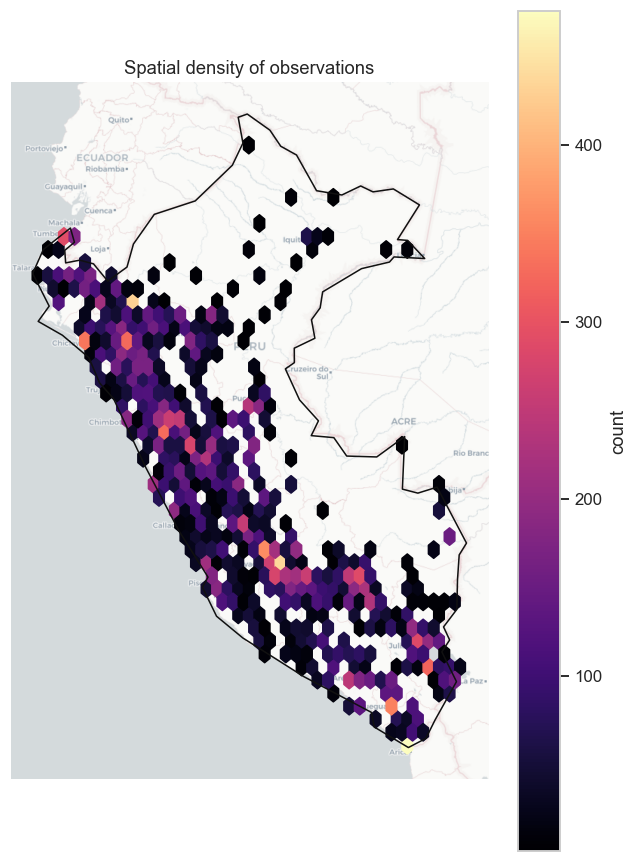

In [10]:
fig, ax = plt.subplots(figsize=(6, 8))
peru_web.boundary.plot(ax=ax, color="#111111", linewidth=1)

hb = ax.hexbin(
    geo_web.geometry.x,
    geo_web.geometry.y,
    gridsize=40,
    cmap="magma",
    mincnt=1,
)
fig.colorbar(hb, ax=ax, label="count")
add_basemap(ax)
ax.set_axis_off()
ax.set_title("Spatial density of observations")
plt.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOT_DIR / "geo_density_hexbin.png", dpi=150)

## Map of output intensity

Output values are right-skewed, so we map log1p(valor_total).

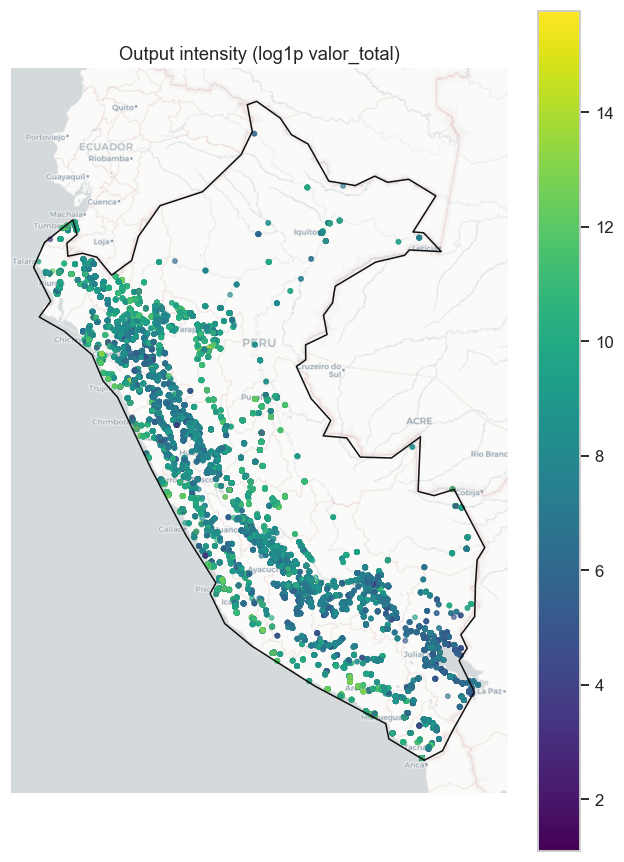

In [11]:
fig, ax = plt.subplots(figsize=(6, 8))
peru_web.boundary.plot(ax=ax, color="#111111", linewidth=1)

plot_df = geo_web.dropna(subset=["log1p_valor_total"]).copy()
plot_df.plot(
    ax=ax,
    column="log1p_valor_total",
    cmap="viridis",
    markersize=8,
    alpha=0.6,
    legend=True,
)
add_basemap(ax)
ax.set_axis_off()
ax.set_title("Output intensity (log1p valor_total)")
plt.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOT_DIR / "geo_output_map.png", dpi=150)

## Map of diversification

Diversification is mapped at capital points to explore spatial clustering.

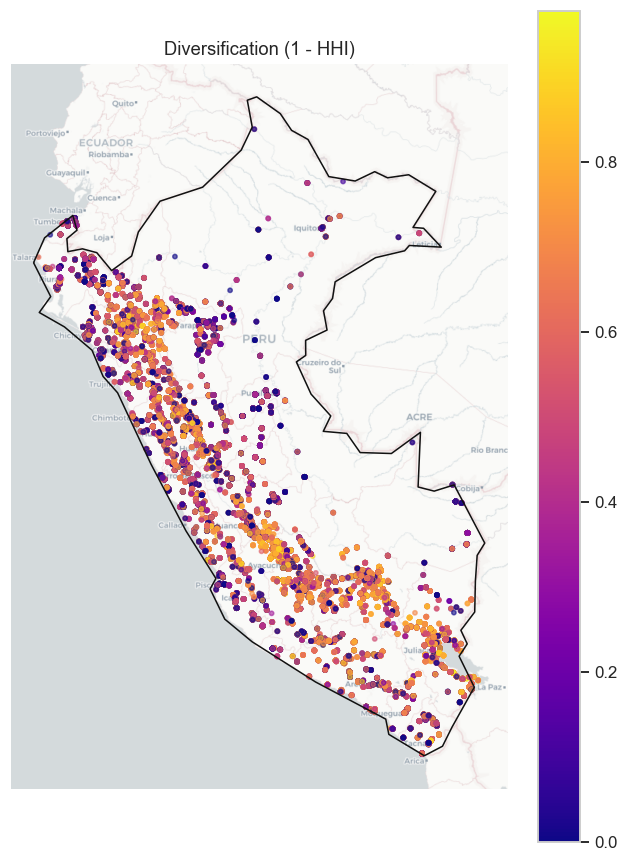

In [12]:
if "diversificacion_area" in geo_web.columns:
    fig, ax = plt.subplots(figsize=(6, 8))
    peru_web.boundary.plot(ax=ax, color="#111111", linewidth=1)

    geo_web.dropna(subset=["diversificacion_area"]).plot(
        ax=ax,
        column="diversificacion_area",
        cmap="plasma",
        markersize=8,
        alpha=0.6,
        legend=True,
    )
    add_basemap(ax)
    ax.set_axis_off()
    ax.set_title("Diversification (1 - HHI)")
    plt.tight_layout()
    if SAVE_PLOTS:
        fig.savefig(PLOT_DIR / "geo_diversification_map.png", dpi=150)

## Climate surfaces

Temperature, precipitation, and elevation are mapped to reveal spatial gradients.

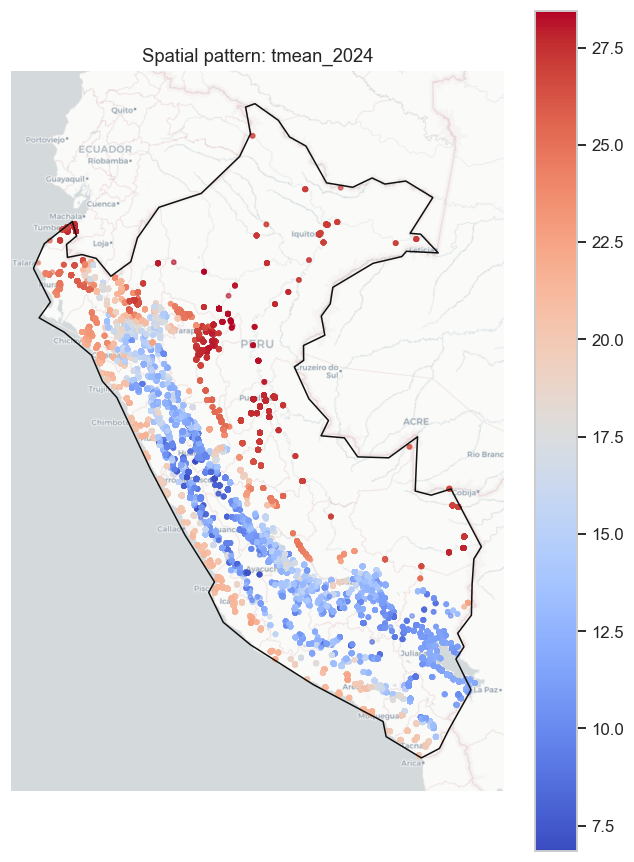

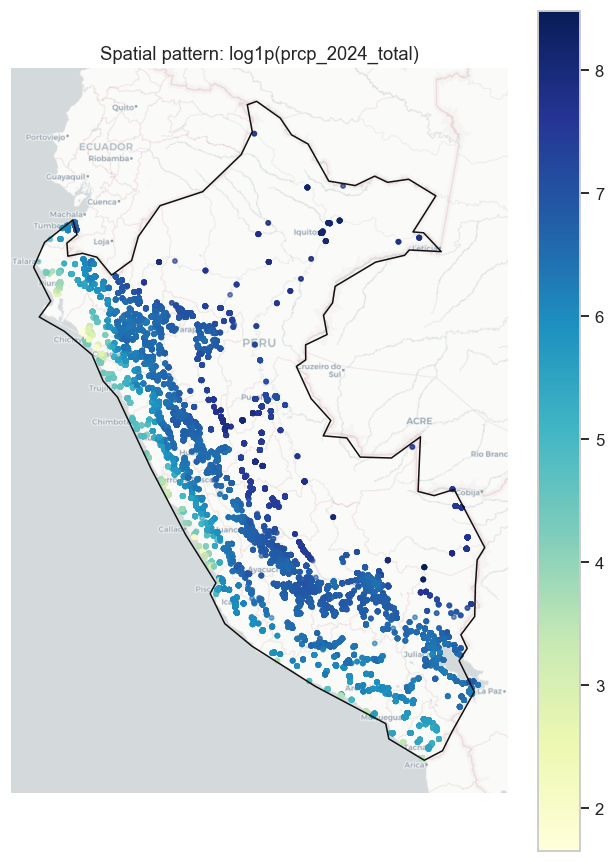

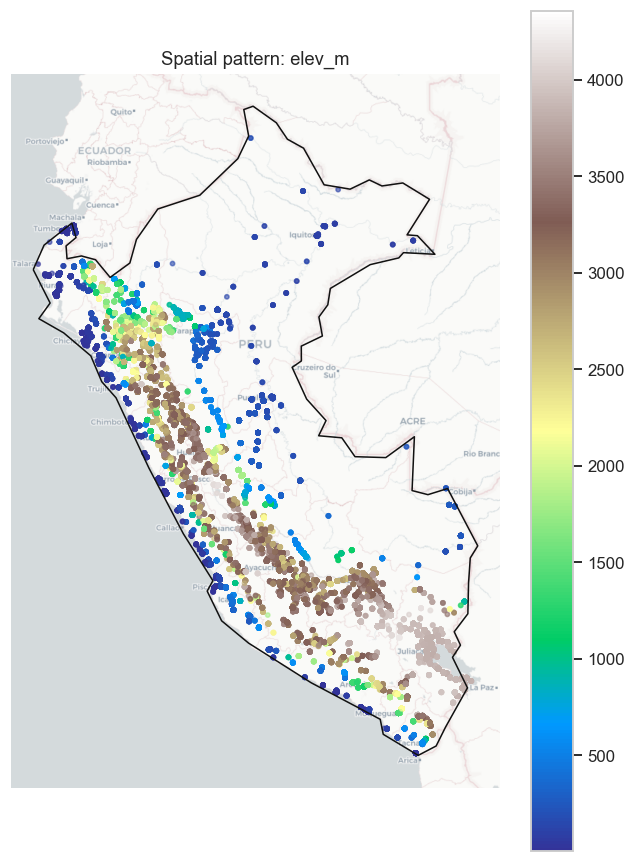

In [13]:
climate_maps = [
    ("tmean_2024", "coolwarm"),
    ("prcp_2024_total", "YlGnBu"),
    ("elev_m", "terrain"),
]

for col, cmap in climate_maps:
    if col not in geo_web.columns:
        continue
    fig, ax = plt.subplots(figsize=(6, 8))
    peru_web.boundary.plot(ax=ax, color="#111111", linewidth=1)

    data = geo_web.dropna(subset=[col]).copy()
    if col == "prcp_2024_total":
        data = data.assign(prcp_log=safe_log1p(data[col]))
        plot_col = "prcp_log"
        label = "log1p(prcp_2024_total)"
    else:
        plot_col = col
        label = col

    data.plot(
        ax=ax,
        column=plot_col,
        cmap=cmap,
        markersize=8,
        alpha=0.6,
        legend=True,
    )
    add_basemap(ax)
    ax.set_axis_off()
    ax.set_title(f"Spatial pattern: {label}")
    plt.tight_layout()
    if SAVE_PLOTS:
        fig.savefig(PLOT_DIR / f"geo_{col}_map.png", dpi=150)

## Spatial bins (grid averages)

Aggregating to a spatial grid reveals regional patterns while reducing noise.

/Users/gabrielsaco/Documents/GitHub/sfa_ciup/venv/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:54: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  return bound(*args, **kwds)


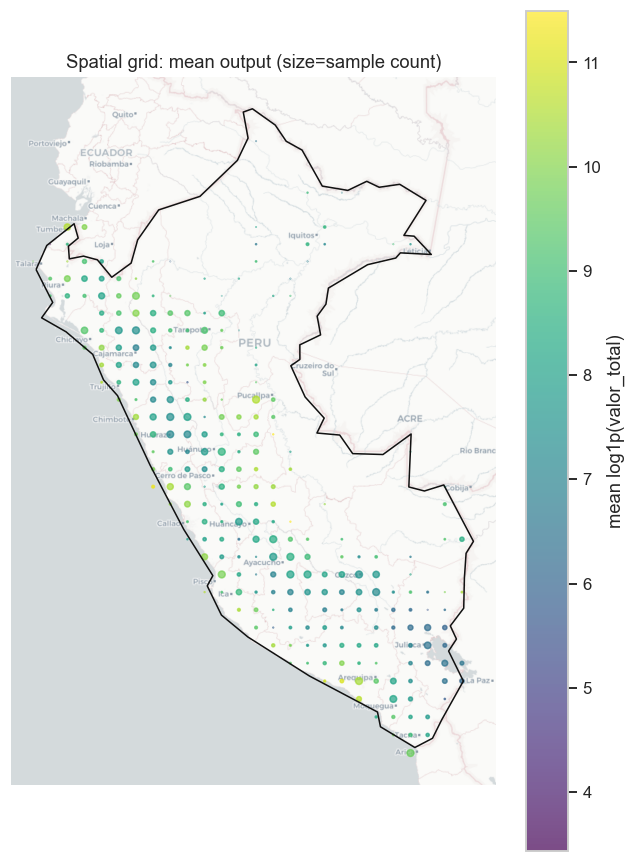

In [14]:
geo_grid = geo2.copy()
geo_grid = geo_grid.dropna(subset=["capital_lat", "capital_lon", "log1p_valor_total"])

geo_grid["lat_bin"] = (geo_grid["capital_lat"] * 2).round() / 2
geo_grid["lon_bin"] = (geo_grid["capital_lon"] * 2).round() / 2

grid_summary = (
    geo_grid.groupby(["lat_bin", "lon_bin"], dropna=False)
    .agg(
        mean_log_output=("log1p_valor_total", "mean"),
        n=("log1p_valor_total", "size"),
    )
    .reset_index()
)

grid_gdf = gpd.GeoDataFrame(
    grid_summary,
    geometry=gpd.points_from_xy(grid_summary["lon_bin"], grid_summary["lat_bin"]),
    crs="EPSG:4326",
)

grid_web = to_web(grid_gdf)

fig, ax = plt.subplots(figsize=(6, 8))
peru_web.boundary.plot(ax=ax, color="#111111", linewidth=1)

sizes = np.clip(grid_web["n"], 1, grid_web["n"].quantile(0.95))
size_scale = 20 * sizes / sizes.max()

sc = ax.scatter(
    grid_web.geometry.x,
    grid_web.geometry.y,
    c=grid_web["mean_log_output"],
    s=size_scale,
    cmap="viridis",
    alpha=0.7,
)

fig.colorbar(sc, ax=ax, label="mean log1p(valor_total)")
add_basemap(ax)
ax.set_axis_off()
ax.set_title("Spatial grid: mean output (size=sample count)")
plt.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOT_DIR / "geo_grid_output_map.png", dpi=150)

## Irrigation prevalence map

Uses controls from the merged dataset (if available) to map irrigation adoption.

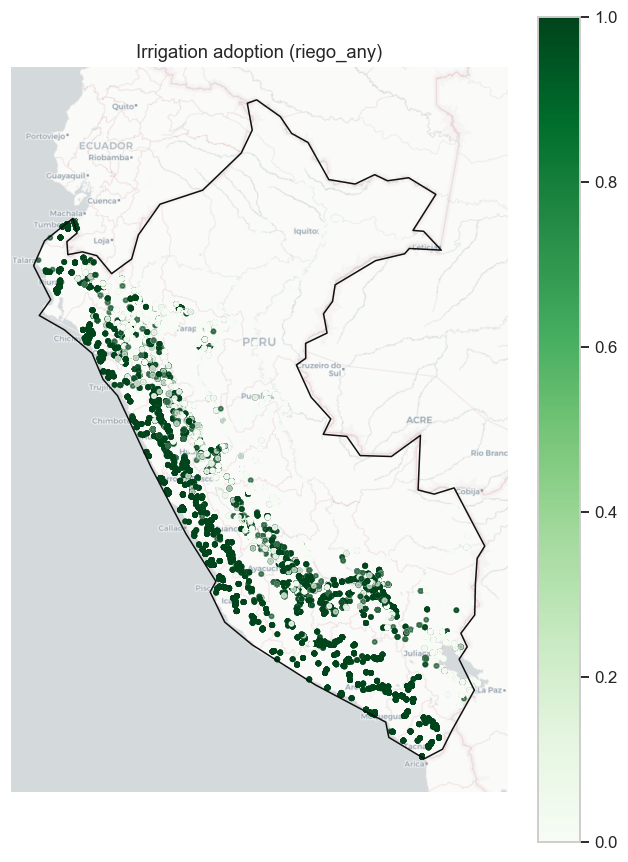

In [15]:
if "riego_any" in geo_web.columns:
    fig, ax = plt.subplots(figsize=(6, 8))
    peru_web.boundary.plot(ax=ax, color="#111111", linewidth=1)

    geo_web.dropna(subset=["riego_any"]).plot(
        ax=ax,
        column="riego_any",
        cmap="Greens",
        markersize=8,
        alpha=0.6,
        legend=True,
    )
    add_basemap(ax)
    ax.set_axis_off()
    ax.set_title("Irrigation adoption (riego_any)")
    plt.tight_layout()
    if SAVE_PLOTS:
        fig.savefig(PLOT_DIR / "geo_irrigation_map.png", dpi=150)

## Climate clusters

Cluster districts by climate/topography to reveal latent agro-ecological zones.

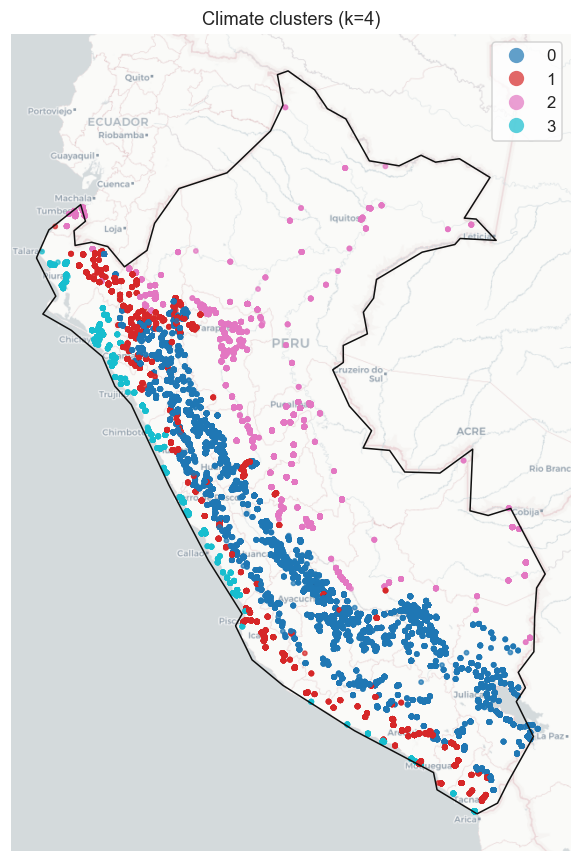

In [16]:
cluster_vars = [
    "tmean_2024",
    "prcp_2024_total",
    "elev_m",
]
cluster_vars = [c for c in cluster_vars if c in geo2.columns]

cluster_df = geo2.dropna(subset=cluster_vars + ["capital_lat", "capital_lon"]).copy()

if cluster_vars:
    X = cluster_df[cluster_vars].copy()
    X["prcp_2024_total"] = safe_log1p(X["prcp_2024_total"]) if "prcp_2024_total" in X.columns else X
    X = (X - X.mean()) / X.std()

    kmeans = KMeans(n_clusters=4, random_state=RANDOM_SEED, n_init=10)
    cluster_df["climate_cluster"] = kmeans.fit_predict(X)

    cluster_gdf = gpd.GeoDataFrame(
        cluster_df,
        geometry=gpd.points_from_xy(cluster_df["capital_lon"], cluster_df["capital_lat"]),
        crs="EPSG:4326",
    )
    cluster_web = to_web(cluster_gdf)

    fig, ax = plt.subplots(figsize=(6, 8))
    peru_web.boundary.plot(ax=ax, color="#111111", linewidth=1)
    cluster_web.plot(
        ax=ax,
        column="climate_cluster",
        categorical=True,
        cmap="tab10",
        markersize=8,
        alpha=0.7,
        legend=True,
    )
    add_basemap(ax)
    ax.set_axis_off()
    ax.set_title("Climate clusters (k=4)")
    plt.tight_layout()
    if SAVE_PLOTS:
        fig.savefig(PLOT_DIR / "geo_climate_clusters.png", dpi=150)

## Latitude/longitude gradients

Simple diagnostics for spatial gradients in temperature and precipitation.

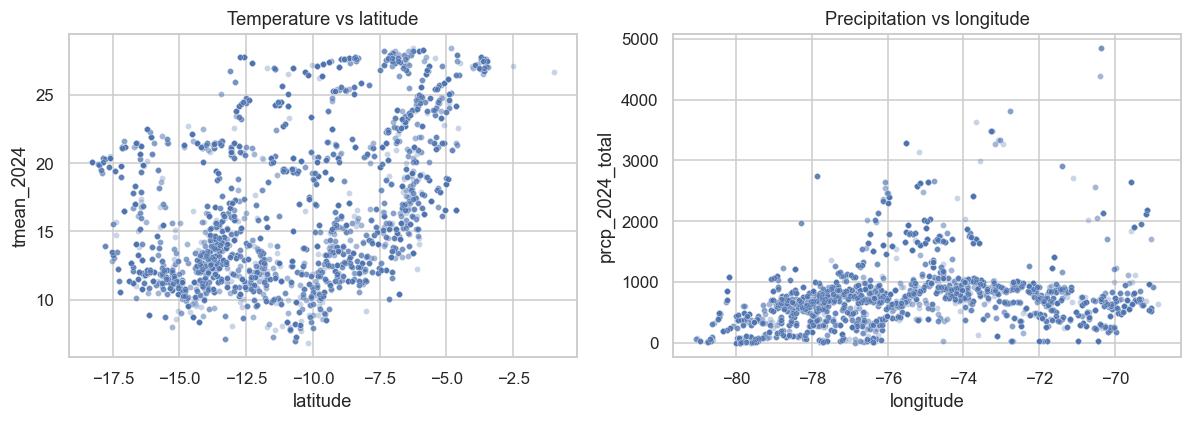

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

if "tmean_2024" in geo2.columns:
    sns.scatterplot(
        data=geo2.sample(n=min(8000, len(geo2)), random_state=RANDOM_SEED),
        x="capital_lat",
        y="tmean_2024",
        alpha=0.3,
        s=15,
        ax=axes[0],
    )
    axes[0].set_title("Temperature vs latitude")
    axes[0].set_xlabel("latitude")
    axes[0].set_ylabel("tmean_2024")

if "prcp_2024_total" in geo2.columns:
    sns.scatterplot(
        data=geo2.sample(n=min(8000, len(geo2)), random_state=RANDOM_SEED),
        x="capital_lon",
        y="prcp_2024_total",
        alpha=0.3,
        s=15,
        ax=axes[1],
    )
    axes[1].set_title("Precipitation vs longitude")
    axes[1].set_xlabel("longitude")
    axes[1].set_ylabel("prcp_2024_total")

plt.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOT_DIR / "geo_lat_lon_gradients.png", dpi=150)

## Collinearity diagnostics

Check correlations among climate/topography variables.

In [18]:
corr_vars = [
    "tmean_2024",
    "delta_tmean_24_23",
    "prcp_2024_total",
    "prcp_total_z",
    "elev_m",
    "slope_deg",
    "ruggedness",
]

corr_vars = [c for c in corr_vars if c in geo2.columns]
geo2_corr = geo2[corr_vars].corr()
geo2_corr

,tmean_2024,delta_tmean_24_23,prcp_2024_total,prcp_total_z,elev_m,slope_deg,ruggedness
tmean_2024,1.000000,0.383926,0.289495,-0.286392,-0.924889,-0.350317,-0.373936
delta_tmean_24_23,0.383926,1.000000,0.382627,-0.183877,-0.180362,-0.215530,-0.223279
prcp_2024_total,0.289495,0.382627,1.000000,0.051860,-0.069069,-0.062329,-0.040868
prcp_total_z,-0.286392,-0.183877,0.051860,1.000000,0.255731,0.048291,0.056055
elev_m,-0.924889,-0.180362,-0.069069,0.255731,1.000000,0.342779,0.368450
slope_deg,-0.350317,-0.215530,-0.062329,0.048291,0.342779,1.000000,0.967973
ruggedness,-0.373936,-0.223279,-0.040868,0.056055,0.368450,0.967973,1.000000


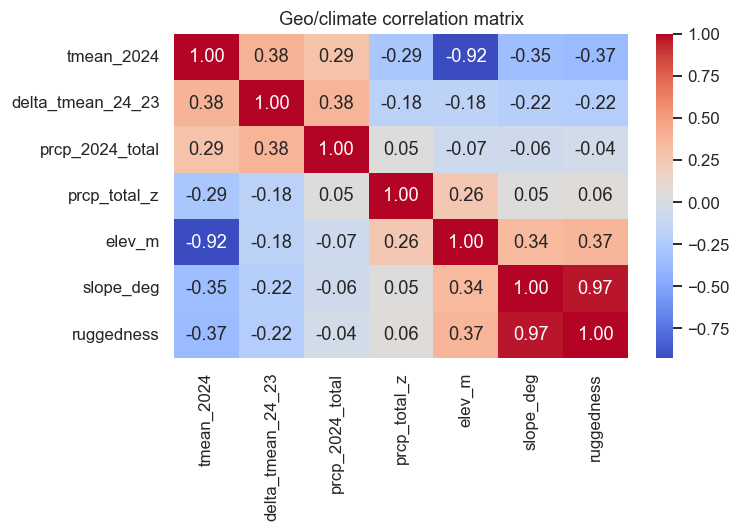

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(geo2_corr, annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Geo/climate correlation matrix")
plt.tight_layout()
if SAVE_PLOTS:
    fig.savefig(PLOT_DIR / "geo_corr_heatmap.png", dpi=150)

## Interpretation

- Spatial density maps show the sampling footprint and identify concentration
  of observations around certain districts.
- Output and diversification maps show visible regional gradients, reinforcing
  the importance of geo controls.
- Climate surfaces (precipitation, temperature, elevation) reveal strong
  geographic structure consistent with Peru’s coast–sierra–selva divide.
- Climate clusters offer a compact, data-driven partition of agro-ecological
  zones that can be used in stratified analyses.
- Correlation diagnostics show which variables may be redundant; precipitation
  and elevation often correlate with temperature, so careful model selection is
  advised.